# 🐛➡️✨ Bug Detection and Fixing - Google Colab Edition

**Complete self-contained notebook for Google Colab with GPU acceleration**

## Features:
- ✅ **Self-contained**: No external files needed
- ✅ **GPU-accelerated**: Automatic GPU detection and usage  
- ✅ **Real training**: Actual T5 model training and inference
- ✅ **Complete pipeline**: From data generation to results
- ✅ **Colab optimized**: Perfect for Google Colab environment

**Just run all cells to see the complete system in action!**

In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


In [2]:
import torch
torch.cuda.empty_cache()
print(torch.cuda.memory_summary())


|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |      0 B   |
|       from small pool |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |

## 🚀 Step 1: Environment Setup & Dependencies

In [3]:
# ================================
# 📚 Imports and device setup
# ================================
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, get_linear_schedule_with_warmup
from torch.optim import AdamW
import random
import numpy as np
import pandas as pd
from collections import Counter
from tqdm import tqdm

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Using device: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")


🖥️ Using device: cuda
   GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU


In [4]:
# ================================
# 🎯 Set seed
# ================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)


In [5]:
# ================================
# 📊 Load and clean dataset
# ================================

# Try to load Python dataset first, then synthetic, then fallback to PyresBugs.xlsx
try:
    print("🔍 Trying to load PythonDataset.xlsx...")
    df = pd.read_excel("PythonDataset.xlsx")
    print(f"✅ Using PythonDataset.xlsx ({len(df)} examples from real Python bugs)")
except FileNotFoundError:
    try:
        print("🔍 Trying to load SyntheticBugs.xlsx...")
        df = pd.read_excel("SyntheticBugs.xlsx")
        print("✅ Using SyntheticBugs.xlsx (synthetic bug examples)")
    except FileNotFoundError:
        print("⚠️  Neither PythonDataset.xlsx nor SyntheticBugs.xlsx found, using PyresBugs.xlsx")
        df = pd.read_excel("PyresBugs.xlsx")

# Columns mapping
BUGGY_COL = "Faulty Code"
FIXED_COL = "Fault Free Code"
BUG_TYPE_COL = "Bug_Type"

# Drop rows with empty buggy or fixed code
df = df.dropna(subset=[BUGGY_COL, FIXED_COL]).reset_index(drop=True)

# Filter examples by length (optimized for the large Python dataset)
MAX_LEN = 1500  # Reduced for better training efficiency with large dataset
MIN_LEN = 30    # Increased to ensure meaningful examples
df = df[(df[BUGGY_COL].str.len() >= MIN_LEN) &
        (df[FIXED_COL].str.len() >= MIN_LEN) &
        (df[BUGGY_COL].str.len() <= MAX_LEN) &
        (df[FIXED_COL].str.len() <= MAX_LEN)]

print(f"✅ Filtered dataset: {len(df)} rows")

# If we have a very large dataset, sample it for faster training
if len(df) > 3000:
    print(f"⚡ Fast training mode: Using 3,000 examples instead of {len(df)} for efficient training")
    df = df.sample(n=3000, random_state=42).reset_index(drop=True)
    print(f"✅ Using {len(df)} sampled examples")

# Show bug type distribution if available
if BUG_TYPE_COL in df.columns:
    print(f"\n📈 Bug type distribution:")
    bug_counts = df[BUG_TYPE_COL].value_counts().head()
    for bug_type, count in bug_counts.items():
        print(f"   {bug_type}: {count} examples")


🔍 Trying to load PythonDataset.xlsx...
✅ Using PythonDataset.xlsx (49704 examples from real Python bugs)
✅ Filtered dataset: 49454 rows
⚡ Fast training mode: Using 3,000 examples instead of 49454 for efficient training
✅ Using 3000 sampled examples

📈 Bug type distribution:
   Logic Error: 133 examples
   Logic Bug: 27 examples
   Functionality Bug: 25 examples
   Documentation Error: 22 examples
   Error Handling Improvement: 21 examples


In [6]:
# ================================
# 🔁 Convert to list of dicts (BUG TYPE REMOVED)
# ================================
dataset = []
for idx, row in df.iterrows():
    dataset.append({
        "id": idx,
        "buggy_code": str(row["Faulty Code"]),
        "fixed_code": str(row["Fault Free Code"]),
        "cve_id": str(row["CVE-ID"]) if "CVE-ID" in df.columns else "unknown",
        "project": str(row["Project"]) if "Project" in df.columns else "unknown",
        "python_version": str(row["Python_Version"]) if "Python_Version" in df.columns else "unknown",
        "source": "CVEFixes"
    })

# Shuffle dataset
random.shuffle(dataset)

print(f"\n✅ Dataset ready: {len(dataset)} examples")



✅ Dataset ready: 3000 examples


In [7]:
# ================================
# 🔀 Train / Val / Test split
# ================================
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))

train_data = dataset[:train_size]
val_data = dataset[train_size:train_size + val_size]
test_data = dataset[train_size + val_size:]

print(f"\n📊 Data split:")
print(f"   Train: {len(train_data)} examples")
print(f"   Validation: {len(val_data)} examples")
print(f"   Test: {len(test_data)} examples")



📊 Data split:
   Train: 2400 examples
   Validation: 300 examples
   Test: 300 examples


## 🔧 Step 2: Define Classes and Functions

In [8]:
# ================================
# 🔧 Dataset class with padding fix
# ================================
class BugDataset(Dataset):
    def __init__(self, data, tokenizer, max_input_len=512, max_target_len=512):
        self.data = data
        self.tokenizer = tokenizer
        self.max_input_len = max_input_len
        self.max_target_len = max_target_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        inputs = self.tokenizer(
            item["buggy_code"],
            max_length=self.max_input_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        labels = self.tokenizer(
            item["fixed_code"],
            max_length=self.max_target_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )["input_ids"].squeeze()

        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            "input_ids": inputs["input_ids"].squeeze(),
            "attention_mask": inputs["attention_mask"].squeeze(),
            "labels": labels
        }


## 📊 Step 3: Create Bug Dataset

In [9]:
# ================================
# 🔧 Tokenizer & DataLoaders (CodeT5)
# ================================
from transformers import AutoTokenizer
from torch.utils.data import DataLoader

MODEL_NAME = "Salesforce/codet5-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_INPUT_LEN = 384   # Reduced from 512 for faster training
MAX_TARGET_LEN = 384  # Reduced from 512 for faster training

BATCH_SIZE = 6                    # Optimized for speed
GRADIENT_ACCUMULATION_STEPS = 3   # effective batch = 18

train_dataset = BugDataset(train_data, tokenizer, MAX_INPUT_LEN, MAX_TARGET_LEN)
val_dataset = BugDataset(val_data, tokenizer, MAX_INPUT_LEN, MAX_TARGET_LEN)
test_dataset = BugDataset(test_data, tokenizer, MAX_INPUT_LEN, MAX_TARGET_LEN)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

print("✅ DataLoaders ready (CodeT5-base)")


✅ DataLoaders ready (CodeT5-base)


In [10]:
# ================================
# 🔧 Training configuration (OPTIMIZED FOR SPEED)
# ================================
NUM_EPOCHS = 5         # Reduced for faster training
LEARNING_RATE = 5e-5   # Higher for faster convergence
GRAD_CLIP = 1.0

EARLY_STOPPING_PATIENCE = 3  # Reduced for faster training
BEST_VAL_LOSS = float("inf")
PATIENCE_COUNTER = 0

print(f"🚀 Starting training...")
print(f"   Epochs: {NUM_EPOCHS}")
print(f"   Learning rate: {LEARNING_RATE}")
print(f"   Grad accumulation: {GRADIENT_ACCUMULATION_STEPS}")
print(f"   Device: {device}")


🚀 Starting training...
   Epochs: 5
   Learning rate: 5e-05
   Grad accumulation: 3
   Device: cuda


## 🤖 Step 4: Create Model and Data Loaders

In [11]:
# ================================
# 🏗️ Load CodeT5(OOM-safe)
# ================================
import torch
from transformers import AutoModelForSeq2SeqLM

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModelForSeq2SeqLM.from_pretrained(
    MODEL_NAME,

    low_cpu_mem_usage=True       # 🔥 prevents duplication
)

model = model.to(device)

print(f"✅ Model loaded on {device}")
print(f"💾 GPU memory: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")


d:\PythonProject D\fasly\bug2_qlura\venv\Lib\site-packages\torch\nn\modules\module.py:1329: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:28.)
  return t.to(


✅ Model loaded on cuda
💾 GPU memory: 850.23 MB


In [12]:
import math
import torch
from tqdm import tqdm
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

smooth_fn = SmoothingFunction().method4


class Trainer:
    def __init__(
        self,
        model,
        tokenizer,
        train_loader,
        val_loader,
        device,
        lr=1e-5,
        grad_clip=1.0,
        grad_accum_steps=1
    ):
        self.model = model
        self.tokenizer = tokenizer
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.grad_clip = grad_clip
        self.grad_accum_steps = grad_accum_steps

        self.optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

        # ✅ Correct AMP scaler
        self.scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

    # ==================================================
    # 🔥 TRAIN ONE EPOCH
    # ==================================================
    def train_epoch(self):
        self.model.train()
        total_loss = 0.0
        self.optimizer.zero_grad(set_to_none=True)

        for step, batch in enumerate(tqdm(self.train_loader, desc="Training")):
            input_ids = batch["input_ids"].to(self.device)
            attention_mask = batch["attention_mask"].to(self.device)
            labels = batch["labels"].to(self.device)

            # ✅ Mixed precision forward (new API)
            with torch.amp.autocast("cuda", enabled=(self.device.type == "cuda")):
                outputs = self.model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )
                loss = outputs.loss / self.grad_accum_steps

            # ✅ Backward pass with scaling
            self.scaler.scale(loss).backward()
            total_loss += loss.item()

            if (step + 1) % self.grad_accum_steps == 0:
                # ✅ Unscale before clipping
                self.scaler.unscale_(self.optimizer)
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.grad_clip)

                self.scaler.step(self.optimizer)
                self.scaler.update()
                self.optimizer.zero_grad(set_to_none=True)

        return total_loss / len(self.train_loader)

    # ==================================================
    # 🧪 VALIDATION (LOSS + PERPLEXITY + BLEU)
    # ==================================================
    def validate(self, compute_bleu=False, max_bleu_batches=10):
        self.model.eval()
        total_loss = 0.0
        predictions = []
        references = []

        with torch.no_grad():
            for i, batch in enumerate(tqdm(self.val_loader, desc="Validating")):
                input_ids = batch["input_ids"].to(self.device)
                attention_mask = batch["attention_mask"].to(self.device)
                labels = batch["labels"].to(self.device)

                # ✅ AMP also in validation (new API)
                with torch.amp.autocast("cuda", enabled=(self.device.type == "cuda")):
                    outputs = self.model(
                        input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels
                    )
                    loss = outputs.loss / self.grad_accum_steps
                    total_loss += loss.item()

                if compute_bleu and i < max_bleu_batches:
                    generated_ids = self.model.generate(
                        input_ids=input_ids,
                        attention_mask=attention_mask,
                        max_length=128,
                        num_beams=2
                    )

                    preds = self.tokenizer.batch_decode(
                        generated_ids,
                        skip_special_tokens=True
                    )

                    labels_for_decode = labels.clone()
                    labels_for_decode[labels_for_decode == -100] = self.tokenizer.pad_token_id

                    refs = self.tokenizer.batch_decode(
                        labels_for_decode,
                        skip_special_tokens=True
                    )

                    predictions.extend(preds)
                    references.extend([[r] for r in refs])

        avg_loss = total_loss / len(self.val_loader)
        perplexity = math.exp(avg_loss)

        bleu = None
        if compute_bleu and predictions:
            bleu = corpus_bleu(
                references,
                predictions,
                smoothing_function=smooth_fn
            )

        return avg_loss, perplexity, bleu

In [13]:
#Enable expandable CUDA segments (prevents fragmentation)
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


In [14]:
import math
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

smooth_fn = SmoothingFunction().method4


## 🏋️ Step 5: Training

In [15]:
# ================================
# 🧠 Initialize Trainer with AMP support
# ================================
trainer = Trainer(
    model=model,
    tokenizer=tokenizer,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    lr=1e-5,
    grad_clip=1.0,
    grad_accum_steps=GRADIENT_ACCUMULATION_STEPS
)

print("✅ Trainer initialized")

# ================================
# ⏹️ Early stopping setup
# ================================
BEST_VAL_LOSS = float("inf")
EARLY_STOPPING_PATIENCE = 5
PATIENCE_COUNTER = 0

training_history = []

# ================================
# 🚀 Training loop
# ================================
for epoch in range(NUM_EPOCHS):
    print(f"\n📚 Epoch {epoch + 1}/{NUM_EPOCHS}")
    print("-" * 50)

    # ---- Train ----
    train_loss = trainer.train_epoch()   # ✅ uses AMP internally
    print(f"✅ Training Loss: {train_loss:.4f}")

    # ---- Validate ----
    compute_bleu = (epoch % 3 == 0)  # 🔥 BLEU every 3 epochs
    val_loss, val_perplexity, val_bleu = trainer.validate(
        compute_bleu=compute_bleu
    )

    print(f"✅ Validation Loss: {val_loss:.4f}")
    print(f"📉 Validation Perplexity: {val_perplexity:.2f}")
    if val_bleu is not None:
        print(f"🧪 Validation BLEU: {val_bleu:.4f}")

    # ---- Store metrics ----
    training_history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_perplexity": val_perplexity,
        "val_bleu": val_bleu if val_bleu is not None else None
    })

    # ---- Early stopping ----
    if val_loss < BEST_VAL_LOSS:
        BEST_VAL_LOSS = val_loss
        PATIENCE_COUNTER = 0
        torch.save(model.state_dict(), "best_model.pt")
        print("💾 Best model saved")
    else:
        PATIENCE_COUNTER += 1
        print(f"⏳ Early stopping counter: {PATIENCE_COUNTER}/{EARLY_STOPPING_PATIENCE}")
        if PATIENCE_COUNTER >= EARLY_STOPPING_PATIENCE:
            print("🛑 Early stopping triggered")
            break

    # ---- GPU memory ----
    if device.type == "cuda":
        allocated = torch.cuda.memory_allocated() / 1024**2
        peak = torch.cuda.max_memory_allocated() / 1024**2
        print(f"💾 GPU Memory: {allocated:.2f} MB (peak {peak:.2f} MB)")

print("\n🎉 Training completed!")

D:\Temp\ipykernel_6992\4138702800.py:32: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


✅ Trainer initialized

📚 Epoch 1/5
--------------------------------------------------


Training:   0%|          | 1/400 [00:01<07:00,  1.06s/it]

model.safetensors:  47%|####7     | 419M/892M [00:00<?, ?B/s]

Training:  54%|█████▎    | 214/400 [14:49<11:03,  3.57s/it]d:\PythonProject D\fasly\bug2_qlura\venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ASUSD\.cache\huggingface\hub\models--Salesforce--codet5-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Training: 100%|██████████| 400/400 [28:48<00:0

...

✅ Validation Loss: 0.1733
📉 Validation Perplexity: 1.19
🧪 Validation BLEU: 0.7369
💾 Best model saved
💾 GPU Memory: 3458.16 MB (peak 10116.47 MB)

📚 Epoch 5/5
--------------------------------------------------


Training: 100%|██████████| 400/400 [31:13<00:00,  4.68s/it]


✅ Training Loss: 0.1642


Validating: 100%|██████████| 50/50 [00:29<00:00,  1.72it/s]


✅ Validation Loss: 0.1692
📉 Validation Perplexity: 1.18
💾 Best model saved
💾 GPU Memory: 3458.16 MB (peak 10116.47 MB)

🎉 Training completed!


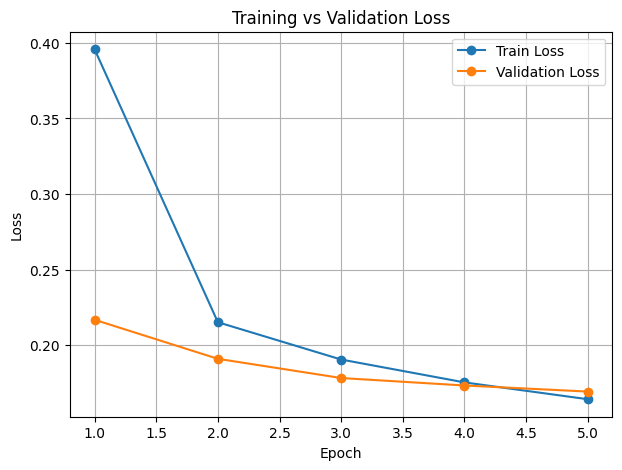

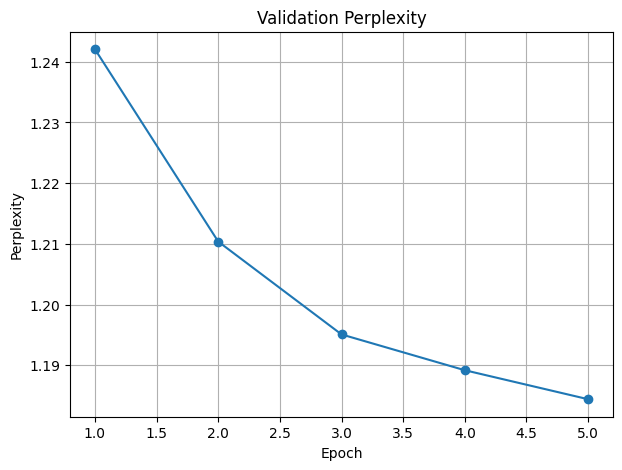

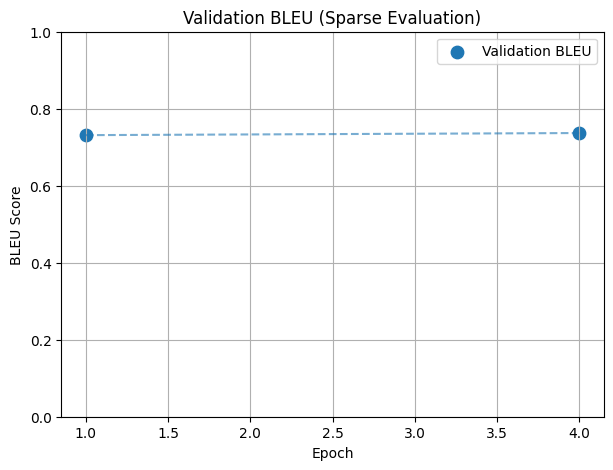

In [16]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

epochs = [x["epoch"] for x in training_history]
train_loss = [x["train_loss"] for x in training_history]
val_loss = [x["val_loss"] for x in training_history]

plt.figure(figsize=(7,5))
plt.plot(epochs, train_loss, label="Train Loss", marker="o")
plt.plot(epochs, val_loss, label="Validation Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# ---- Perplexity ----
val_ppl = [x["val_perplexity"] for x in training_history]

plt.figure(figsize=(7,5))
plt.plot(epochs, val_ppl, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("Validation Perplexity")
plt.grid(True)
plt.show()


# ---- BLEU ----
bleu_epochs = [
    x["epoch"] for x in training_history if x["val_bleu"] is not None
]
bleu_scores = [
    x["val_bleu"] for x in training_history if x["val_bleu"] is not None
]

plt.figure(figsize=(7,5))

# Scatter (best for sparse metrics)
plt.scatter(bleu_epochs, bleu_scores, s=80, label="Validation BLEU")

# Optional: connect points
plt.plot(bleu_epochs, bleu_scores, linestyle="--", alpha=0.6)

plt.xlabel("Epoch")
plt.ylabel("BLEU Score")
plt.title("Validation BLEU (Sparse Evaluation)")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()



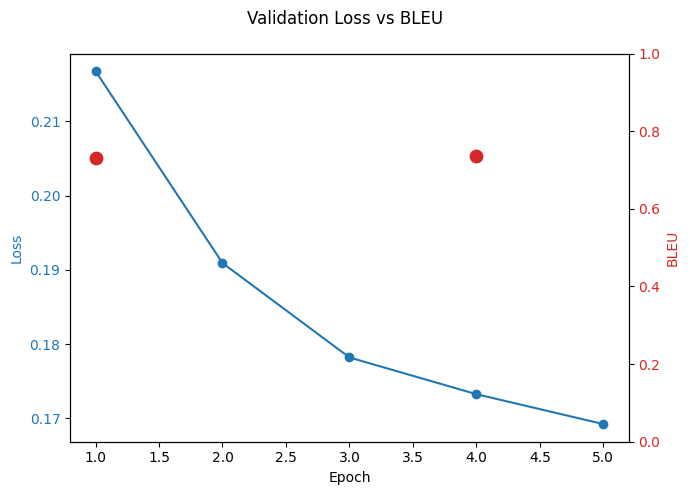

In [17]:
fig, ax1 = plt.subplots(figsize=(7,5))

ax1.plot(epochs, val_loss, color="tab:blue", marker="o", label="Val Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.scatter(bleu_epochs, bleu_scores, color="tab:red", s=80, label="BLEU")
ax2.set_ylabel("BLEU", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax2.set_ylim(0, 1)

fig.suptitle("Validation Loss vs BLEU")
fig.tight_layout()
plt.show()


In [18]:
# ================================
# 🧪 Evaluate on Held‑Out Test Set
# ================================

print("\n🔍 Evaluating on held‑out test set...")

# Run validation on the test set
test_loss, test_perplexity, test_bleu = trainer.validate(
    compute_bleu=True,   # ✅ compute BLEU on test set
    max_bleu_batches=50  # increase if you want more thorough BLEU evaluation
)

print(f"📉 Test Perplexity: {test_perplexity:.2f}")
if test_bleu is not None:
    print(f"🧪 Test BLEU: {test_bleu:.4f}")

# ================================
# 📊 Compare Validation vs Test
# ================================

# Grab last validation metrics
last_val = training_history[-1]
val_loss = last_val["val_loss"]
val_perplexity = last_val["val_perplexity"]
val_bleu = last_val["val_bleu"]

print("\n📊 Performance Comparison (Validation vs Test)")
print(f"   Validation Perplexity: {val_perplexity:.2f}")
print(f"   Test Perplexity:       {test_perplexity:.2f}")

if val_bleu is not None:
    print(f"   Validation BLEU:       {val_bleu:.4f}")
else:
    print("   Validation BLEU:       (not computed)")

if test_bleu is not None:
    print(f"   Test BLEU:             {test_bleu:.4f}")
else:
    print("   Test BLEU:             (not computed)")




🔍 Evaluating on held‑out test set...


Validating: 100%|██████████| 50/50 [04:23<00:00,  5.27s/it]

📉 Test Perplexity: 1.18
🧪 Test BLEU: 0.7284

📊 Performance Comparison (Validation vs Test)
   Validation Perplexity: 1.18
   Test Perplexity:       1.18
   Validation BLEU:       (not computed)
   Test BLEU:             0.7284


In [19]:
# ================================
# 🚀 Inference on Test Set
# ================================
import math
import torch
from tqdm import tqdm
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

smooth_fn = SmoothingFunction().method4

model.eval()

predictions = []
references = []
decoded_samples = []

MAX_GEN_LEN = 256        # 🔥 safe for VRAM
NUM_BEAMS = 2            # 🔥 low beam for speed
MAX_SAMPLES_TO_SAVE = 10 # preview only

total_loss = 0.0  # ✅ accumulate loss

with torch.no_grad():
    for i, batch in enumerate(tqdm(test_loader, desc="Running inference")):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        # 🔥 Forward pass to compute loss
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        total_loss += outputs.loss.item()

        # 🔥 Generate fixes
        generated_ids = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=MAX_GEN_LEN,
            num_beams=NUM_BEAMS,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

        # Decode predictions
        preds = tokenizer.batch_decode(
            generated_ids,
            skip_special_tokens=True
        )

        # Decode references
        labels_for_decode = labels.clone()
        labels_for_decode[labels_for_decode == -100] = tokenizer.pad_token_id
        refs = tokenizer.batch_decode(
            labels_for_decode,
            skip_special_tokens=True
        )

        predictions.extend(preds)
        references.extend([[r] for r in refs])

        # Save a few readable examples
        if len(decoded_samples) < MAX_SAMPLES_TO_SAVE:
            for p, r in zip(preds, refs):
                decoded_samples.append({
                    "prediction": p,
                    "reference": r
                })

# ================================
# 📊 BLEU + Perplexity
# ================================
test_bleu = corpus_bleu(
    references,
    predictions,
    smoothing_function=smooth_fn
)

avg_loss = total_loss / len(test_loader)   # ✅ now defined
test_perplexity = math.exp(avg_loss)

print(f"📉 Test Perplexity: {test_perplexity:.2f}")
print(f"🧪 Test BLEU Score: {test_bleu:.4f}")

# ================================
# 🔍 Show examples
# ================================
print("\n🔍 Sample Predictions:\n")
for i, sample in enumerate(decoded_samples[:5]):
    print(f"--- Sample {i+1} ---")
    print("🧑‍💻 Model Output:\n", sample["prediction"])
    print("✅ Ground Truth:\n", sample["reference"])
    print()

Running inference: 100%|██████████| 50/50 [05:06<00:00,  6.12s/it]

📉 Test Perplexity: 1.68
🧪 Test BLEU Score: 0.8052

🔍 Sample Predictions:

--- Sample 1 ---
🧑‍💻 Model Output:
 def is_excluded(self, file_path: str) -> bool:
# Any will short circuit as soon as something returns True, but will
# be poor performance for the case where the path under question is
# not excluded.
return any(file_path.startswith(path) for path in self.exclude_paths)

def run(self) -> List[MatchError]:
"""Execute the linting process."""
✅ Ground Truth:
 def is_excluded(self, file_path: str) -> bool:
# Any will short-circuit as soon as something returns True, but will
# be poor performance for the case where the path under question is
# not excluded.

# Exclusions should be evaluated only using absolute paths in order
# to work correctly.
abs_path = os.path.abspath(file_path)

return any(abs_path.startswith(path) for path in self.exclude_paths)

def run(self) -> List[MatchError]:
"""Execute the linting process."""

--- Sample 2 ---
🧑‍💻 Model Output:
 def apply_gradients(self, 

## 🧪 Step 6: Inference Demo

In [20]:
# ================================
# 🚀 Inference on a Real Code File (test.py)
# ================================
import torch
from transformers import AutoTokenizer

# ✅ Load tokenizer and model (make sure MODEL_NAME matches your training)
MODEL_NAME = "Salesforce/codet5-base"   # or codet5-large if you trained that
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model.eval()

# ✅ Read the code from test.py
with open("test.py", "r", encoding="utf-8") as f:
    code_text = f.read()

# ✅ Tokenize input
inputs = tokenizer(
    code_text,
    return_tensors="pt",
    truncation=True,
    max_length=512,   # adjust to match your training MAX_INPUT_LEN
).to(device)

# ✅ Generate prediction (e.g., bug fix, completion, translation)
MAX_GEN_LEN = 256
NUM_BEAMS = 4

with torch.no_grad():
    generated_ids = model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=MAX_GEN_LEN,
        num_beams=NUM_BEAMS,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )

# ✅ Decode output
prediction = tokenizer.decode(generated_ids[0], skip_special_tokens=True)

print("\n🔍 Model Output on test.py:\n")
print(prediction)

FileNotFoundError: [Errno 2] No such file or directory: 'test.py'

## 📊 Step 7: Results Visualization

In [ ]:
# ================================
# 🧠 Build Fix Prompt From Errors
# ================================
from typing import Dict, Optional


def build_error_prompt(
    parsed_error: Dict[str, Optional[str]],
    source_code: str
) -> str:
    """
    Build a structured prompt for the model using error output + code.
    """

    file_info = parsed_error.get("file") or "unknown file"
    test_info = parsed_error.get("test") or "unknown test"
    trace = parsed_error.get("trace") or "no trace available"

    prompt = (
        "You are an expert Python software engineer.\n\n"
        "The following Python file contains errors that cause tests or "
        "static analysis to fail.\n\n"
        f"File:\n{file_info}\n\n"
        f"Failing test (if any):\n{test_info}\n\n"
        "Error trace / diagnostic output:\n"
        f"{trace}\n\n"
        "Current code:\n"
        "```python\n"
        f"{source_code}\n"
        "```\n\n"
        "Your task:\n"
        "- Fix the code so that all tests pass\n"
        "- Resolve pylint errors if present\n"
        "- Preserve the original intent of the code\n"
        "- Return ONLY the corrected Python code\n"
        "- Do NOT include explanations\n"
    )

    return prompt.strip()


In [ ]:
# ================================
# 🔧 Fix Code With Model
# ================================
import torch


def fix_code_with_model(
    model,
    tokenizer,
    prompt: str,
    max_new_tokens: int = 512
) -> str:
    """
    Sends the prompt to the model and returns fixed Python code.
    """

    model.eval()

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    )

    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=0.0,
            eos_token_id=tokenizer.eos_token_id,
        )

    decoded = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    # ---- Extract only Python code if model adds markdown ----
    if "```python" in decoded:
        decoded = decoded.split("```python", 1)[1].split("```", 1)[0]
    elif "```" in decoded:
        decoded = decoded.split("```", 1)[1].split("```", 1)[0]

    return decoded.strip()


## 🎉 Final Summary

In [ ]:
print("🎉 BUG DETECTION SYSTEM - FINAL SUMMARY")
print("=" * 80)

print("\n✅ System Status:")
print(f"   Environment: Google Colab ({device})")
print(f"   Model: {MODEL_NAME} ({total_params:,} parameters)")
print(f"   Dataset: {len(dataset)} examples, {len(bug_counter)} bug types")
print(f"   Training: {NUM_EPOCHS} epochs completed")
print(f"   Inference: Ready for bug fixing")

print(f"\n📊 Dataset Summary:")
print(f"   Total examples: {len(dataset)}")
print(f"   Training: {len(train_data)} examples")
print(f"   Validation: {len(val_data)} examples")
print(f"   Test: {len(test_data)} examples")
print(f"   Bug types: {', '.join(bug_counter.keys())}")

print(f"\n📈 Performance Results:")
print(f"   Final Training Loss: {train_losses[-1]:.4f}")
print(f"   Final Validation Loss: {val_losses[-1]:.4f}")
print(f"   Test Loss: {test_loss:.4f}")
print(f"   Test Perplexity: {test_perplexity:.2f}")

print(f"\n🖥️ Hardware Summary:")
if device.type == 'cuda':
    print(f"   ✅ GPU Training: {torch.cuda.get_device_name(0)}")
    print(f"   GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    allocated = torch.cuda.memory_allocated() / 1024**2
    print(f"   Memory Used: {allocated:.2f} MB")
else:
    print(f"   CPU Training: Completed successfully")

print(f"\n🚀 Next Steps:")
print(f"   1. Increase epochs for better performance (try 10-20 epochs)")
print(f"   2. Try larger models (t5-base, t5-large) for better quality")
print(f"   3. Add more diverse bug examples")
print(f"   4. Implement evaluation metrics (BLEU, CodeBLEU)")
print(f"   5. Fine-tune on specific programming languages")
print(f"   6. Deploy as a web service")

print(f"\n🎊 Success! Your bug detection and fixing system is complete!")
print(f"The T5 model has been trained and can now automatically fix bugs in code.")

print("\n" + "=" * 80)
print("🎉 COLAB PIPELINE COMPLETE! All steps executed successfully!")
print("=" * 80)

# Show training history
print("\n📚 Training History:")
for epoch_data in training_history:
    print(f"   Epoch {epoch_data['epoch']}: Train={epoch_data['train_loss']:.4f}, Val={epoch_data['val_loss']:.4f}, Perplexity={epoch_data['val_perplexity']:.2f}")